In [2]:
import pandas as pd
df=pd.read_csv('data set.csv')
df.head()

,Patient_ID,Patient_Name,Age,Gender,Disease,Admission_Date,Discharge_Date,Doctor,Department,City,Blood_Group,Insurance,Treatment_Cost,Status,Room_Type
0,P0001,Amber Boyd,56.0,Female,Heart Disease,6/19/2025,6/20/2025,Dr. Perry,Endocrinology,Karenborough,AB-,Yes,99612.0,Recovered,Semi-Private
1,P0002,Joseph Turner,22.0,Female,Typhoid,7/17/2025,7/29/2025,Dr. Perez,Cardiology,East Monica,A-,Yes,74845.0,Recovered,Semi-Private
2,P0003,Joshua Shelton DVM,54.0,Male,Heart Disease,5/3/2025,5/14/2025,Dr. Murphy,Infectious Disease,Pageside,AB+,No,93013.0,Under Treatment,General
3,P0004,Michele Ballard,75.0,Male,COVID-19,4/11/2025,4/20/2025,Dr. Smith,Infectious Disease,Brettborough,AB-,No,52475.0,Under Treatment,Private
4,P0005,Desiree Huffman,4.0,Female,Typhoid,1/25/2025,2/2/2025,Dr. Kent,Pulmonology,Roweborough,B-,Yes,47335.0,Under Treatment,General


In [4]:
df.tail()

,Patient_ID,Patient_Name,Age,Gender,Disease,Admission_Date,Discharge_Date,Doctor,Department,City,Blood_Group,Insurance,Treatment_Cost,Status,Room_Type,Grade
996,P0997,Jennifer White,43.0,Male,Typhoid,8/17/2025,8/18/2025,Dr. Baker,General Medicine,New Kenneth,B-,Yes,40577.0,Recovered,Private,A
997,P0998,James Michael,8.0,Male,COVID-19,2/22/2025,3/7/2025,Dr. Swanson,Pulmonology,Freemanview,A+,Yes,49229.0,Recovered,Private,A+
998,P0999,Courtney Washington,45.0,Male,Typhoid,11/25/2025,12/5/2025,Dr. Cox,Endocrinology,North Jay,AB-,No,68063.0,Recovered,Private,A
999,P1000,Pamela Davis,22.0,Female,Heart Disease,4/21/2025,5/4/2025,Dr. Garcia,Infectious Disease,North Heidi,AB-,No,54985.0,Recovered,Semi-Private,A+
1000,Dengue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient_ID      1001 non-null   object 
 1   Patient_Name    1000 non-null   object 
 2   Age             1000 non-null   float64
 3   Gender          999 non-null    object 
 4   Disease         999 non-null    object 
 5   Admission_Date  1000 non-null   object 
 6   Discharge_Date  1000 non-null   object 
 7   Doctor          1000 non-null   object 
 8   Department      999 non-null    object 
 9   City            999 non-null    object 
 10  Blood_Group     1000 non-null   object 
 11  Insurance       1000 non-null   object 
 12  Treatment_Cost  1000 non-null   float64
 13  Status          999 non-null    object 
 14  Room_Type       999 non-null    object 
 15  Grade           1001 non-null   object 
dtypes: float64(2), object(14)
memory usage: 125.3+ KB


In [6]:
df.columns

Index(['Patient_ID', 'Patient_Name', 'Age', 'Gender', 'Disease',
       'Admission_Date', 'Discharge_Date', 'Doctor', 'Department', 'City',
       'Blood_Group', 'Insurance', 'Treatment_Cost', 'Status', 'Room_Type',
       'Grade'],
      dtype='object')

In [7]:
df.describe()

,Age,Treatment_Cost
count,1000.00000,1000.00000
mean,45.61900,52528.08200
std,25.89522,26998.01667
min,1.00000,5079.00000
25%,23.00000,30462.25000
50%,47.00000,51223.50000
75%,68.00000,76096.50000
max,90.00000,99619.00000


In [15]:
df.isnull().sum()

,0
Patient_ID,0
Patient_Name,0
Age,0
Gender,0
Disease,0
Admission_Date,0
Discharge_Date,0
Doctor,0
Department,0
City,0


Calculate total disease

In [9]:
df['Disease'].value_counts()

,count
Disease,
Malaria,140
COVID-19,131
Heart Disease,130
Asthma,128
Hypertension,122
Dengue,122
Diabetes,114
Typhoid,112


calculate disease average

In [10]:
average_treatment_cost_by_disease = df.groupby('Disease')['Treatment_Cost'].mean()
df['Average'] = df['Disease'].map(average_treatment_cost_by_disease)
df[['Disease','Average']].head(4)

,Disease,Average
0,Heart Disease,54296.230769
1,Typhoid,52363.446429
2,Heart Disease,54296.230769
3,COVID-19,52017.328244


assigning age grade

In [3]:
def grade(age):
    if age <= 30:
        return 'A+'
    elif age <= 45:
        return 'A'
    elif age <= 60:
        return 'B+'
    elif age <= 75:
        return 'B'
    else:
        return 'C'
df['Grade'] = df['Age'].apply(grade)
df[['Disease', 'Age', 'Grade']].head(4)

,Disease,Age,Grade
0,Heart Disease,56.0,B+
1,Typhoid,22.0,A+
2,Heart Disease,54.0,B+
3,COVID-19,75.0,B


gender-wise count

In [11]:
df['Gender'].value_counts()

,count
Gender,
Female,502
Male,497


Treatment distrubution

In [12]:
def treatment_justification(disease):
    if disease == 'Fever':
        return 'Reduce body temperature'
    elif disease == 'Diabetes':
        return 'Control blood sugar levels'
    elif disease == 'Hypertension':
        return 'Maintain normal blood pressure'
    elif disease == 'Asthma':
        return 'Improve breathing'
    else:
        return 'General treatment'

df['Treatment_Justification'] = df['Disease'].apply(treatment_justification)

df[['Disease', 'Treatment_Justification']].head()

,Disease,Treatment_Justification
0,Heart Disease,General treatment
1,Typhoid,General treatment
2,Heart Disease,General treatment
3,COVID-19,General treatment
4,Typhoid,General treatment


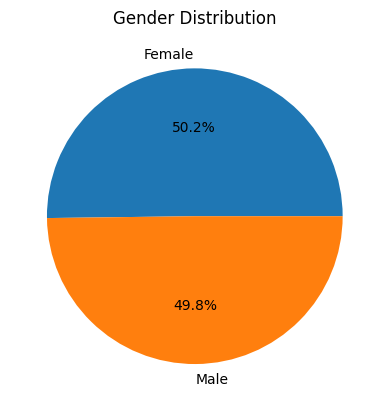

In [31]:
import matplotlib.pyplot as plt

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

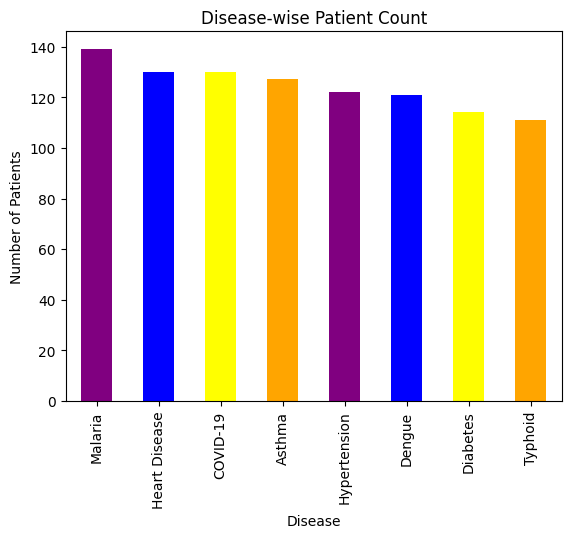

In [17]:
import matplotlib.pyplot as plt
disease_counts=df['Disease'].value_counts()
disease_counts.plot(kind='bar',color=['purple','blue','yellow','orange'])
plt.title('Disease-wise Patient Count')
plt.xlabel('Disease')
plt.ylabel('Number of Patients')
plt.show()

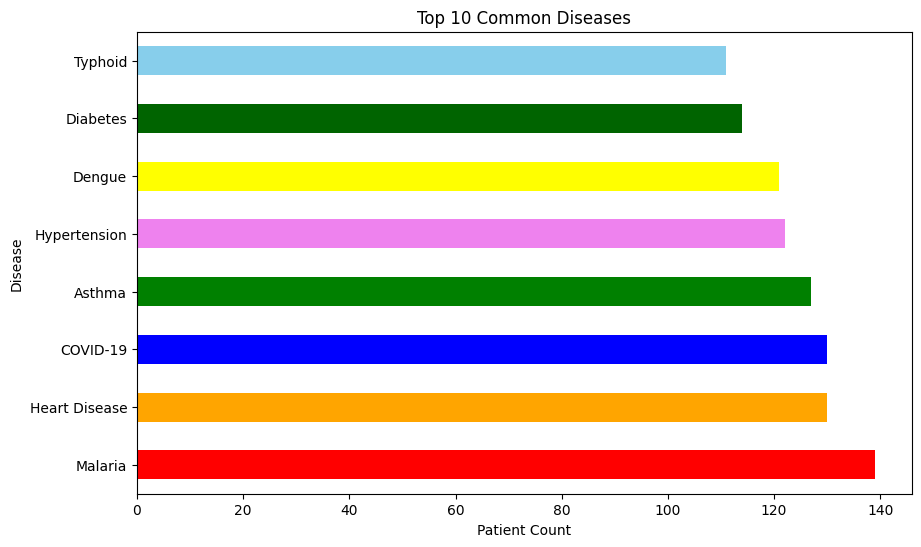

In [25]:
import matplotlib.pyplot as plt
top10 = df['Disease'].value_counts().head(10)
plt.figure(figsize=(10,6))
top10.plot(kind='barh',color=['red','orange','blue','green','violet','yellow','darkgreen','skyblue'])
plt.title('Top 10 Common Diseases')
plt.xlabel('Patient Count')
plt.ylabel('Disease')
plt.show()